In [1]:
import os

os.environ["JAX_PLATFORM_NAME"] = "cpu"

import joblib
import optax.projections
%load_ext autoreload
%autoreload 2

import jax
import jax.numpy as jnp
import equinox as eqx

import numpy as np
import matplotlib.pyplot as plt

from qdots_qll.distributions import Distribution, update_particles_locations, update_weights

import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error

from jax import jit
from jax.scipy.linalg import expm

from qdots_qll.models.single_dot_weak_coupling_GAME import *

from qdots_qll.resamplers import LWResamplerBounds

from qdots_qll.exp_design import OptimizeInitialStateMeasurements, MaxDetFimExpDesign

from tensorflow_probability.substrates import jax as tfp
import optax

import jax.tree_util as jtu


def tree_stack(trees):
    return jax.tree.map(lambda *v: jnp.stack(v), *trees)


def tree_unstack(tree):
    leaves, treedef = jax.tree.flatten(tree)
    return [treedef.unflatten(leaf) for leaf in zip(*leaves, strict=True)]


def transpose_results(pytree):
    return tree_stack(list(map(list, zip(*tree_unstack(tree_unstack(pytree))))))


In [118]:
from scipy.stats import binned_statistic

In [259]:
# re = joblib.load("results_one_qubit/run_2024-05-31_19-38-19")
# 
# outcomes, times, exp_values, covs, p_init_states, p_basis = re
# 
# outcomes = outcomes.transpose(1, 0, 2)
# times = times.T
# exp_values = exp_values.transpose(1, 0, 2)
# covs = covs.transpose(1, 0, 2, 3)
# p_init_states = p_init_states.transpose(1, 0, 2)
# p_basis = p_basis.transpose(1, 0, 2)
# 
# no_rv = covs.shape[2]
# no_runs = covs.shape[0]
# no_iterations = covs.shape[1]
# 
# covs_mean = np.mean(covs, axis=0)
# covs_std = np.std(covs, axis=0)
# 
# fig, axs = plt.subplots(2, 2, dpi=300)
# 
# for i, ax in enumerate(axs.flatten()):
#     y = covs_mean[:, i, i]
#     y_std = covs_std[:, i, i]
#     ax.plot(y)
#     ax.fill_between(x=np.arange(no_iterations), y1=y + y_std, y2=y - y_std, alpha=0.5)
#     ax.loglog()
# 
# plt.tight_layout()
# plt.show()
# 
# det_covs_runs = jax.vmap(lambda run: jax.vmap(lambda run: jnp.linalg.det(run))(run))(covs)
# plt.plot(np.mean(det_covs_runs, axis=0))
# plt.loglog()
# plt.show()
# 
# plt.hist(np.array(times).flatten(), bins=200)
# plt.show()
# 
# cumtimes = np.cumsum(times, axis=1)
# for i in range(4):
#     y, _, _ = binned_statistic(cumtimes.flatten(), covs.reshape(-1, *covs.shape[2:])[:, i, i], statistic='mean',
#                                bins=300)
#     plt.plot(y)
#     plt.loglog()
# plt.show()
# 
# y, _, _ = binned_statistic(cumtimes.flatten(), det_covs_runs.flatten(), statistic='mean', bins=300)
# plt.plot(y)
# plt.loglog()
# plt.show()


In [258]:
# re = joblib.load("results_one_qubit/run_2024-05-31_20-14-00")
# 
# outcomes, times, exp_values, covs, p_init_states, p_basis = re
# 
# outcomes = outcomes.transpose(1, 0, 2)
# times = times.T
# exp_values = exp_values.transpose(1, 0, 2)
# covs = covs.transpose(1, 0, 2, 3)
# p_init_states = p_init_states.transpose(1, 0, 2)
# p_basis = p_basis.transpose(1, 0, 2)
# 
# no_rv = covs.shape[2]
# no_runs = covs.shape[0]
# no_iterations = covs.shape[1]
# 
# covs_mean = np.mean(covs, axis=0)
# covs_std = np.std(covs, axis=0)
# 
# fig, axs = plt.subplots(2, 2, dpi=300)
# 
# for i, ax in enumerate(axs.flatten()):
#     y = covs_mean[:, i, i]
#     y_std = covs_std[:, i, i]
#     ax.plot(y)
#     ax.fill_between(x=np.arange(no_iterations), y1=y + y_std, y2=y - y_std, alpha=0.5)
#     ax.loglog()
# 
# plt.tight_layout()
# plt.show()
# 
# det_covs_runs = jax.vmap(lambda run: jax.vmap(lambda run: jnp.linalg.det(run))(run))(covs)
# plt.plot(np.mean(det_covs_runs, axis=0))
# plt.loglog()
# plt.show()
# 
# plt.hist(np.array(times).flatten(), bins=200)
# plt.show()
# 
# y, _, _ = binned_statistic(cumtimes.flatten(), det_covs_runs.flatten(), statistic='mean', bins=300)
# plt.plot(y)
# plt.loglog()
# plt.show()

In [257]:
# mean_p_init_states = np.mean(p_init_states, axis=0)
# for i in range(4):
#     plt.plot(mean_p_init_states[:, i], label=str(i))
# 
# plt.legend()
# plt.show()
# 
# mean_p_basis = np.mean(p_basis, axis=0)
# for i in range(3):
#     plt.plot(mean_p_basis[:, i], label=str(i))
# 
# plt.legend()
# plt.show()


In [260]:
# plt.hist(np.array(times).flatten(), bins=200)
# plt.show()

In [261]:
# plt.hist(np.array(times).flatten(), bins=200)
# plt.show()

In [2]:
from scipy.stats import binned_statistic

In [3]:
# data: array
from collections import namedtuple


def process_data(data_array, no_bins=300):
    ProcessedData = namedtuple('ProcessedData', [
        'outcomes', 'times', 'exp_values', 'covs',
        'p_init_states', 'p_basis', 'cumtimes_binned',
        'covs_mean_binned', 'covs_std_binned',
        'det_covs_mean_binned', 'det_covs_std_binned'
    ])

    # data_array = re
    # no_bins = 300

    outcomes, times, exp_values, covs, p_init_states, p_basis = data_array

    outcomes = outcomes.transpose(1, 0, 2)
    times = times.T
    exp_values = exp_values.transpose(1, 0, 2)
    covs = covs.transpose(1, 0, 2, 3)
    p_init_states = p_init_states.transpose(1, 0, 2)
    p_basis = p_basis.transpose(1, 0, 2)

    no_rv = covs.shape[2]
    no_runs = covs.shape[0]
    no_iterations = covs.shape[1]

    covs_mean = np.mean(covs, axis=0)
    covs_std = np.std(covs, axis=0)

    det_covs_runs = jax.vmap(lambda run: jax.vmap(lambda run: jnp.linalg.det(run))(run))(covs)

    cumtimes = np.cumsum(times, axis=1)

    cumtimes_binned, _, _ = binned_statistic(cumtimes.flatten(), cumtimes.flatten(), statistic='mean', bins=no_bins)

    det_covs_mean_binned, _, _ = binned_statistic(cumtimes.flatten(), det_covs_runs.flatten(), statistic='mean',
                                                  bins=no_bins)

    det_covs_std_binned, _, _ = binned_statistic(cumtimes.flatten(), det_covs_runs.flatten(), statistic='std',
                                                 bins=no_bins)

    covs_mean_binned = np.zeros([cumtimes_binned.shape[0], no_rv, no_rv])
    covs_std_binned = np.zeros([cumtimes_binned.shape[0], no_rv, no_rv])

    for i in range(no_rv):
        for j in range(no_rv):
            y, _, _ = binned_statistic(cumtimes.flatten(), covs.reshape(-1, *covs.shape[2:])[:, i, j], statistic='mean',
                                       bins=no_bins)
            covs_mean_binned[:, i, j] = y

            y, _, _ = binned_statistic(cumtimes.flatten(), covs.reshape(-1, *covs.shape[2:])[:, i, j], statistic='std',
                                       bins=no_bins)
            covs_std_binned[:, i, j] = y

    # return outcomes, times, exp_values, covs, p_init_states, p_basis, cumtimes_binned, covs_mean_binned, covs_std_binned, det_covs_mean_binned, det_covs_std_binned
    processed_data = ProcessedData(
        outcomes, times, exp_values, covs,
        p_init_states, p_basis, cumtimes_binned,
        covs_mean_binned, covs_std_binned,
        det_covs_mean_binned, det_covs_std_binned
    )

    return processed_data


In [6]:
unoptimized = process_data(joblib.load("results_one_qubit/run_2024-05-31_20-14-00"))
# 
# optimized_accumulate = process_data(joblib.load("results_one_qubit/run_2024-05-31_19-38-19"))
# 
# optimized_not_accumulate = process_data(joblib.load("results_one_qubit/run_2024-06-03_16-52-55"))
# 
t_optimized = process_data(joblib.load("results_one_qubit/run_2024-06-03_18-18-45"))
# 
# rand_t_then_optimized_dont_propagate = process_data(joblib.load("results_one_qubit/run_2024-06-03_23-08-04"))
# 
all_accumulate_with_adam = process_data(joblib.load("results_one_qubit/run_2024-06-03_23-42-38"))
# 
trace = process_data(joblib.load("results_one_qubit/run_2024-06-04_00-04-17"))


In [290]:
# list_of_data = [optimized_not_accumulate, unoptimized, optimized_accumulate, t_optimized, rand_t_then_optimized_dont_propagate, all_accumulate_with_adam, trace]
# names_list = ["Opt not acc", "Vanilla", "Full opt", 't opt', 'rand t+opt+dontpropagate', 'all accumulate with adam', 'trace']

In [7]:
list_of_data = [unoptimized, t_optimized, all_accumulate_with_adam, trace]
names_list = ["Vanilla", 't opt', 'all accumulate with adam', 'trace']

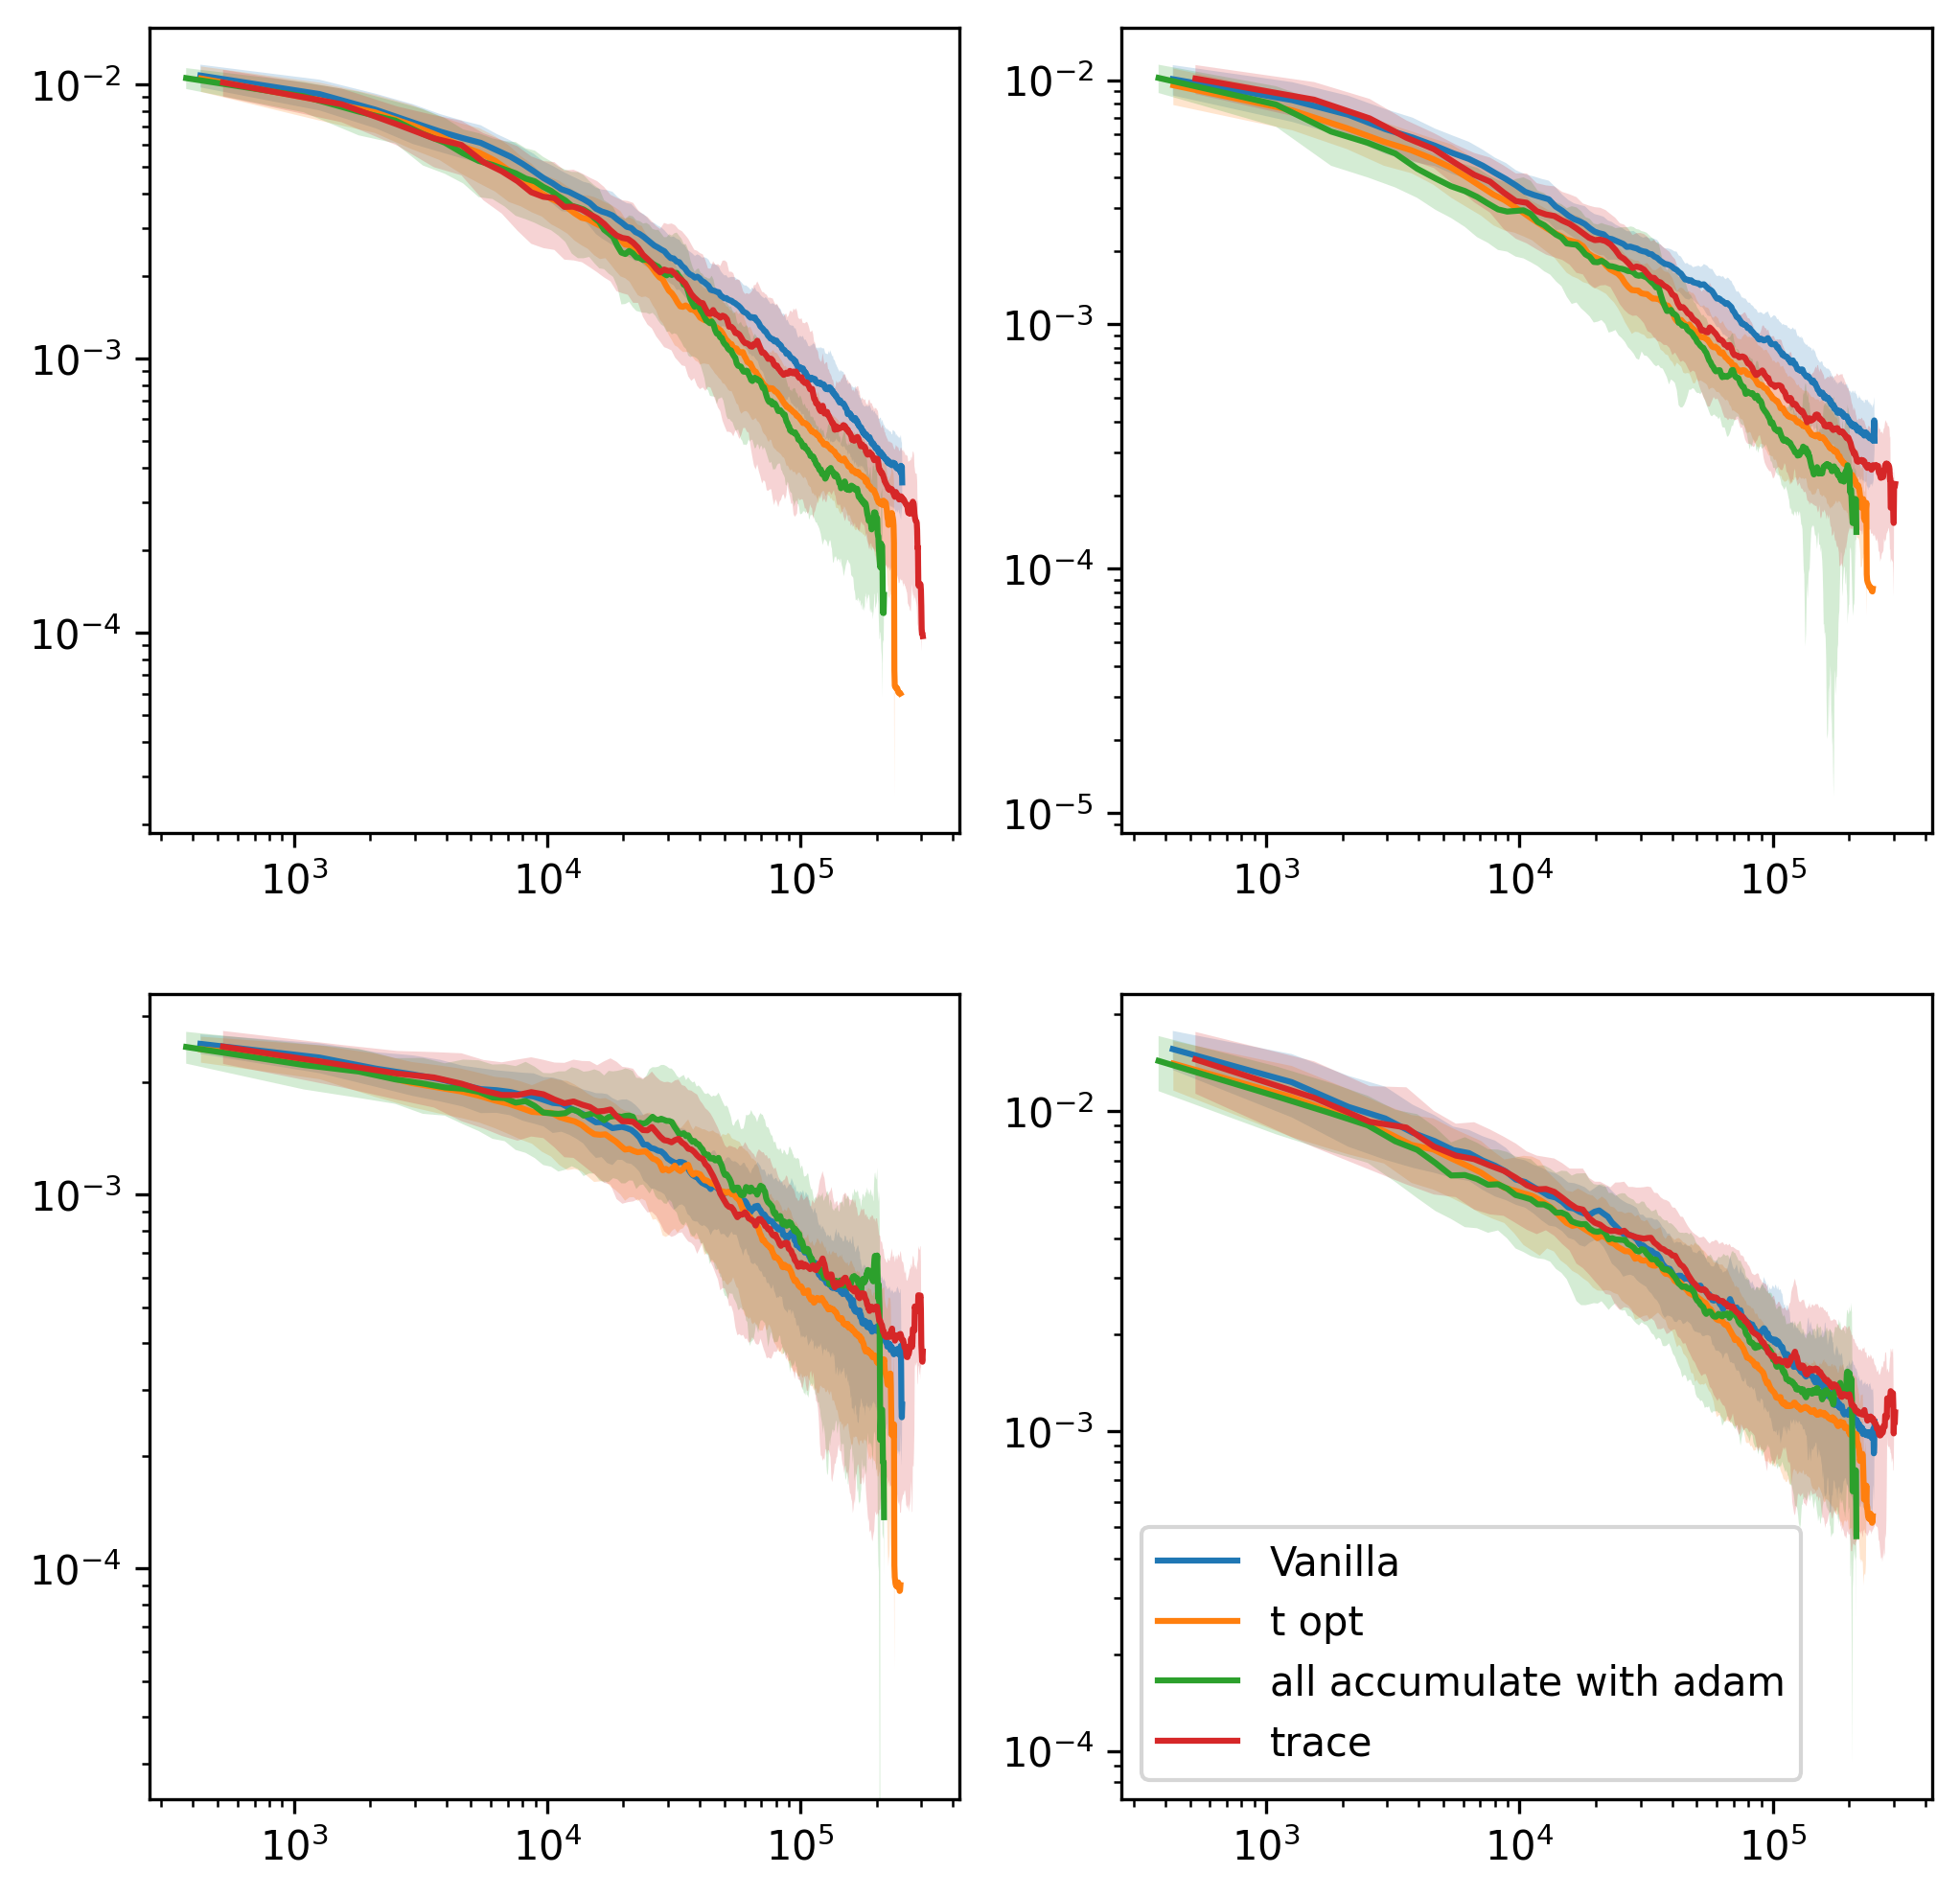

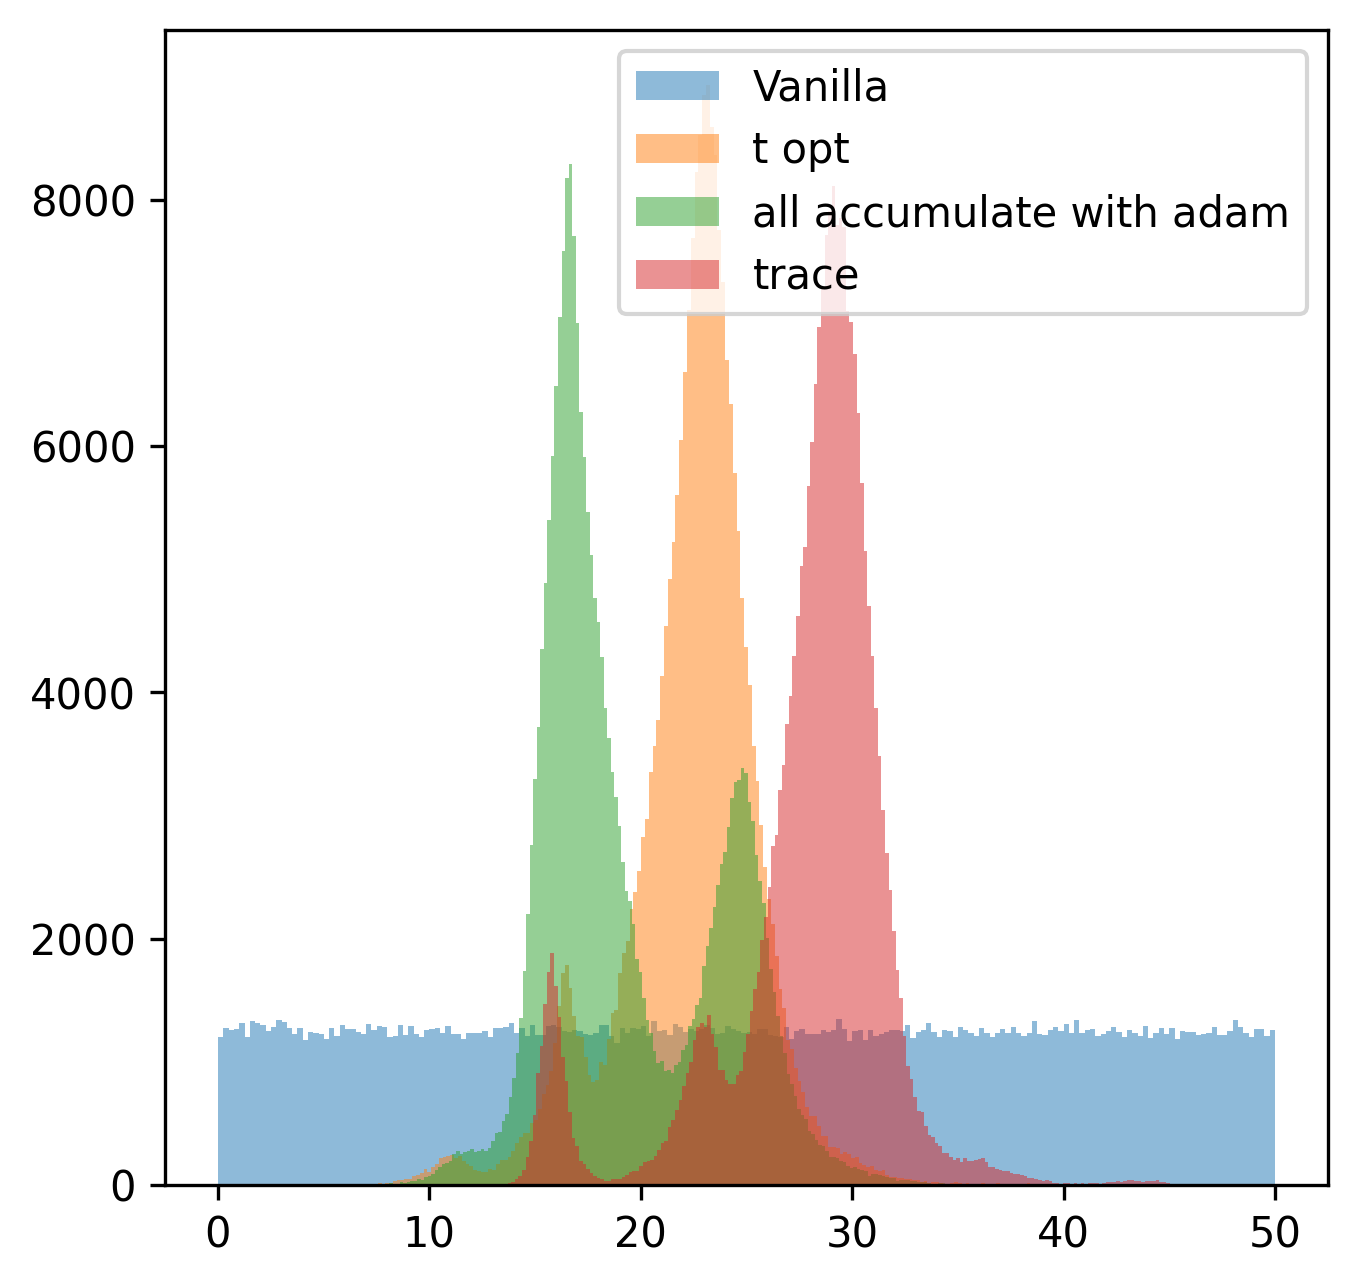

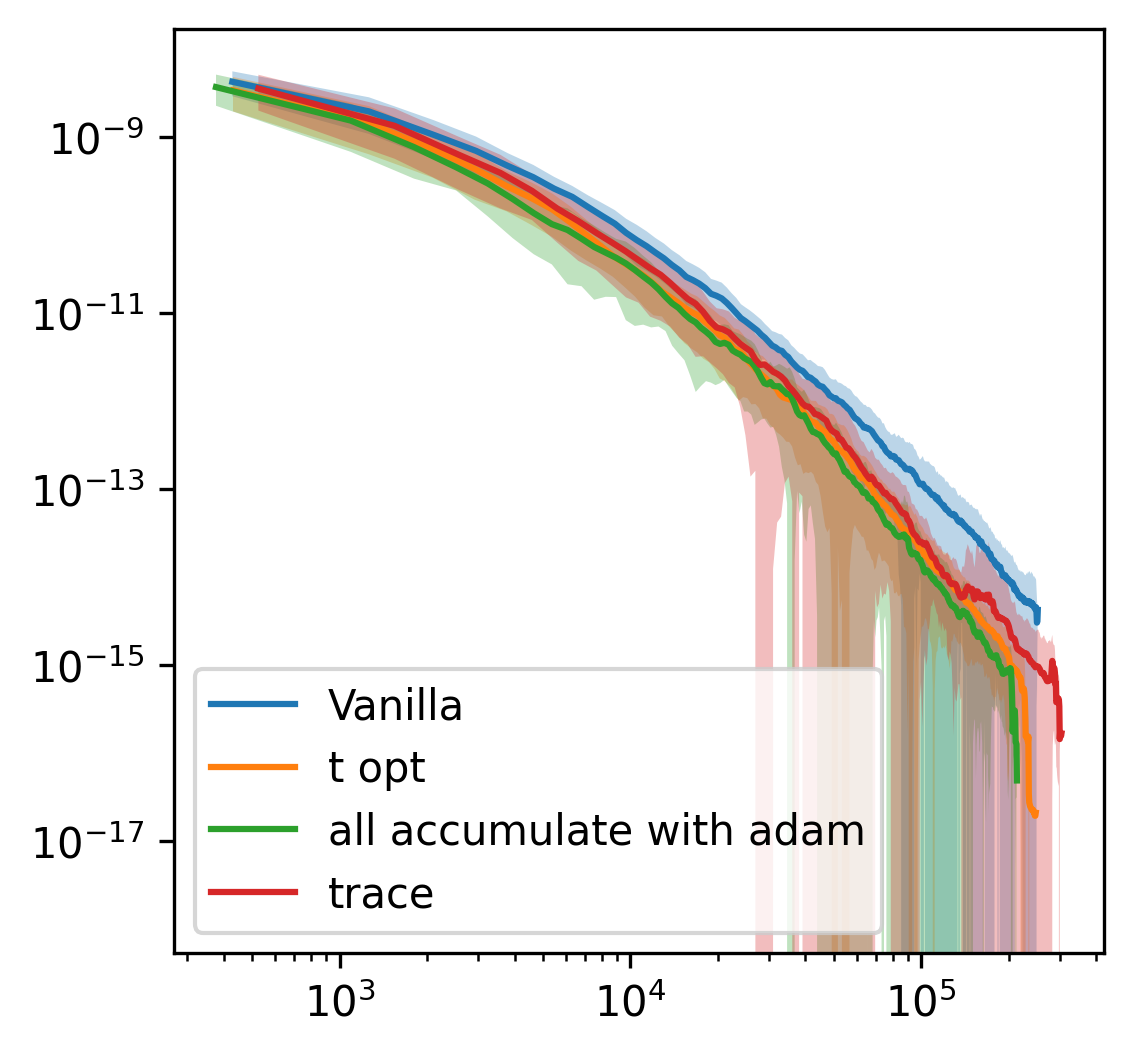

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(8, 8), dpi=300)

for i, ax in enumerate(axs.flatten()):
    for j, data_i in enumerate(list_of_data):
        y = data_i.covs_mean_binned[:, i, i]
        y_std = data_i.covs_std_binned[:, i, i]
        x = data_i.cumtimes_binned

        ax.plot(x, y, label=names_list[j])
        ax.fill_between(x=x, y1=y + y_std, y2=y - y_std, alpha=0.2)
        ax.loglog()

plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
for j, data_i in enumerate(list_of_data):
    ax.hist(np.array(data_i.times).flatten(), bins=200, label=names_list[j], alpha=0.5)

plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(4, 4), dpi=300)

for j, data_i in enumerate(list_of_data):
    x = data_i.cumtimes_binned
    y = data_i.det_covs_mean_binned[:]
    y_std = data_i.det_covs_std_binned[:]

    ax.plot(x, y, label=names_list[j])
    ax.fill_between(x=x, y1=y + y_std, y2=y - y_std, alpha=0.3)
    ax.loglog()

plt.legend()
plt.show()








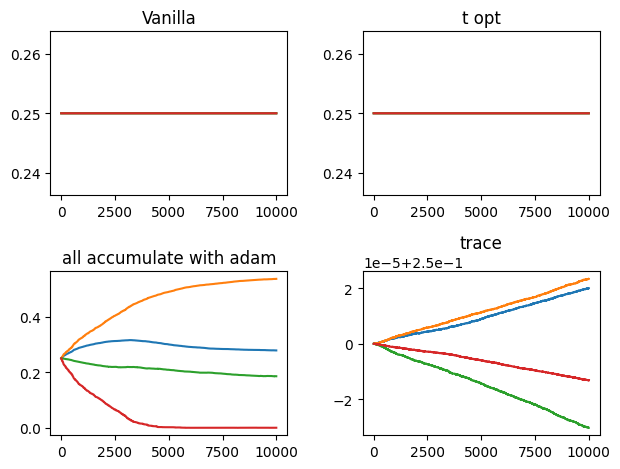

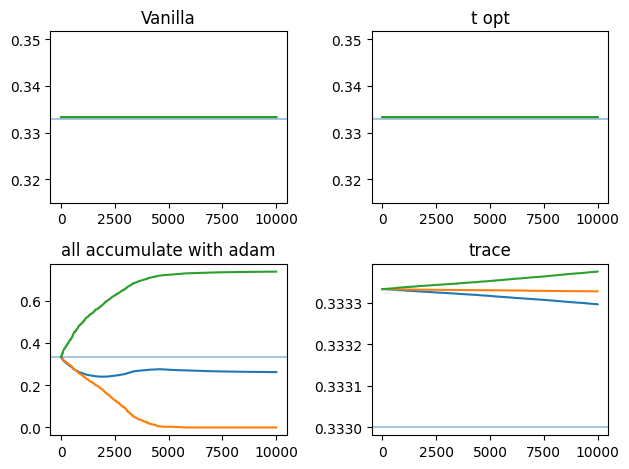

In [18]:
fig, axs = plt.subplots(2, 2, )

# states_names = ["1", "2", "3", "4"]
for i, ax in enumerate(axs.flatten()):
    data_i = list_of_data[i]

    x = np.arange(data_i.p_init_states.shape[1])
    y = data_i.p_init_states.mean(axis=0)[:, :]

    ax.set_title(names_list[i])
    ax.plot(x, y, )  #label=names_list[i])
    # ax.set_ylim(0, 1)

# plt.legend()
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(2, 2, )

# states_names = ["1", "2", "3", "4"]
for i, ax in enumerate(axs.flatten()):
    data_i = list_of_data[i]
    x = np.arange(data_i.p_basis.shape[1])
    y = data_i.p_basis.mean(axis=0)[:, :]
    # y_std = data_i.p_init_states.std(axis=0)[:, i]

    ax.set_title(names_list[i])
    ax.plot(x, y, )  #label=names_list[i])
    ax.axhline(0.333, alpha=0.4)
    # ax.fill_between(x=x, y1=y + y_std, y2=y - y_std, alpha=0.3)
    # ax.set_ylim(0, 1)

# plt.legend()
plt.tight_layout()
plt.show()

In [21]:
m = SingleDotWeakCouplingGAME()

In [22]:
true_parameters

Array([ 0.3142169 ,  0.35833007,  0.05385149, -0.33369482], dtype=float32)

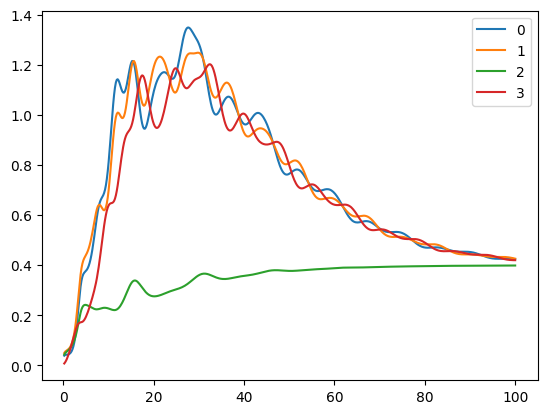

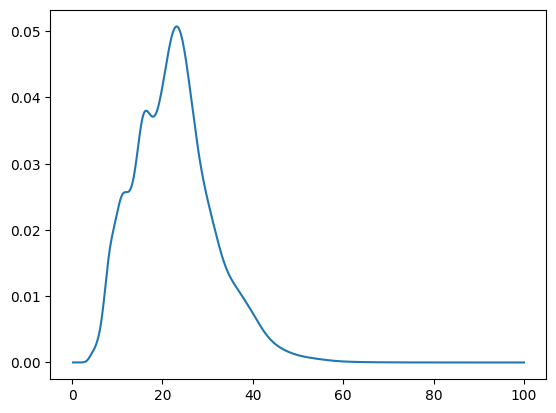

In [46]:
times = jnp.linspace(0, 100., 500)

fim_times = jax.vmap(lambda t: m.fim(true_parameters, t, jnp.ones(4)/4, jnp.ones(3)/3))(times)

det_fim_times = jax.vmap(lambda t: jnp.linalg.det(m.fim(true_parameters, t, jnp.ones(4)/4, jnp.ones(3)/3)))(times)


for i in range(4):
    plt.plot(times, fim_times[:, i, i], label=str(i))
    
plt.legend()
plt.show()


plt.plot(times, det_fim_times)

In [47]:
all_accumulate_with_adam.p_basis.mean(0)[-1].round(3)

Array([0.26200002, 0.        , 0.73800004], dtype=float32)

In [48]:
all_accumulate_with_adam.p_init_states.mean(0)[-1].round(3)

Array([0.27800003, 0.535     , 0.186     , 0.001     ], dtype=float32)

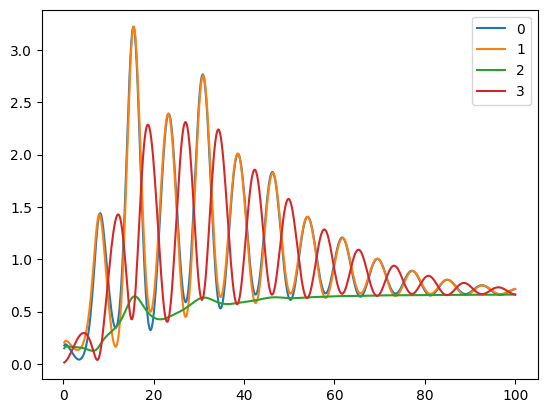

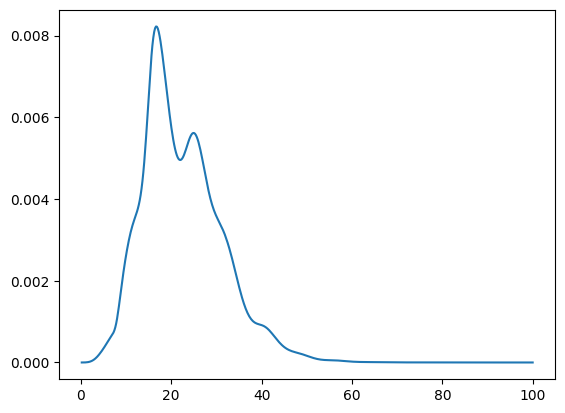

In [51]:
times = jnp.linspace(0, 100., 500)

pstate = all_accumulate_with_adam.p_init_states.mean(0)[-1]
pbasis = all_accumulate_with_adam.p_basis.mean(0)[-1]
fim_times = jax.vmap(lambda t: m.fim(true_parameters, t, pstate, pbasis))(times)

det_fim_times = jax.vmap(lambda t: jnp.linalg.det(m.fim(true_parameters, t,pstate, pbasis)))(times)


for i in range(4):
    plt.plot(times, fim_times[:, i, i], label=str(i))
    
plt.legend()
plt.show()

plt.plot(times, det_fim_times)
plt.show()

In [52]:
0.008/0.005

1.6